In [7]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')



import numpy as np

# Parameters
sequencing_depth = 500
variant_frequency = 0.01

# Simulate one sequencing experiment
variant_reads = np.random.binomial(
    n=sequencing_depth,
    p=variant_frequency
)

print(f"Sequencing depth: {sequencing_depth}")
print(f"Variant-supporting reads: {variant_reads}")


Sequencing depth: 500
Variant-supporting reads: 7


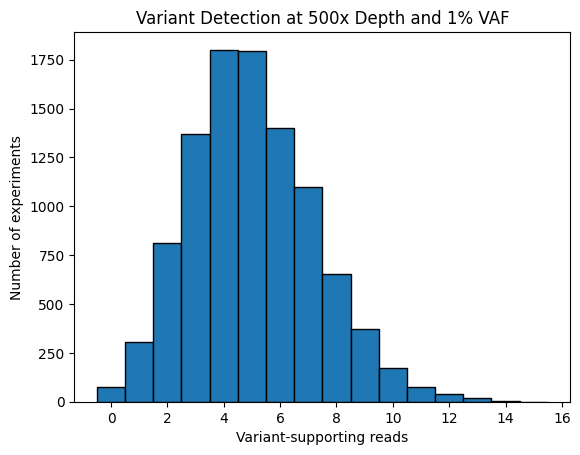

Detection rate: 99.23%


In [8]:

import numpy as np
import matplotlib.pyplot as plt

# Experimental parameters
depth = 500
vaf = 0.01
n_simulations = 10000

# Simulate 10,000 sequencing experiments
variant_reads = np.random.binomial(
    n=depth,
    p=vaf,
    size=n_simulations
)

# Visualize the distribution
plt.hist(
    variant_reads,
    bins=np.arange(variant_reads.max() + 2) - 0.5,
    edgecolor="black"
)

plt.xlabel("Variant-supporting reads")
plt.ylabel("Number of experiments")
plt.title("Variant Detection at 500x Depth and 1% VAF")
plt.show()

# Calculate probability of detecting at least one variant read
detection_rate = np.mean(variant_reads >= 1)

print(f"Detection rate: {detection_rate:.2%}")


In [9]:

# Compare different detection thresholds
for threshold in [1, 2, 3, 5, 10]:
    detection_rate = np.mean(variant_reads >= threshold)

    print(
        f"Threshold: {threshold:2d} reads | "
        f"Detection rate: {detection_rate:.2%}"
    )


Threshold:  1 reads | Detection rate: 99.23%
Threshold:  2 reads | Detection rate: 96.18%
Threshold:  3 reads | Detection rate: 88.05%
Threshold:  5 reads | Detection rate: 56.33%
Threshold: 10 reads | Detection rate: 3.09%


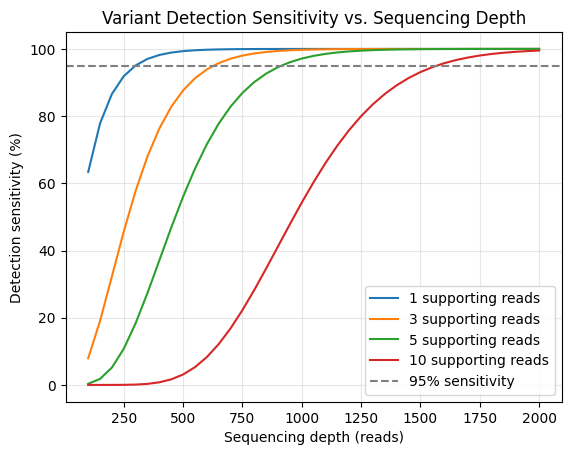

In [10]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

# Parameters
vaf = 0.01
depths = np.arange(100, 2001, 50)
thresholds = [1, 3, 5, 10]

for threshold in thresholds:
    sensitivity = binom.sf(
        threshold - 1,
        depths,
        vaf
    )

    plt.plot(
        depths,
        sensitivity * 100,
        label=f"{threshold} supporting reads"
    )

plt.axhline(95, color="gray",
            linestyle="--", label="95% sensitivity")

plt.xlabel("Sequencing depth (reads)")
plt.ylabel("Detection sensitivity (%)")
plt.title("Variant Detection Sensitivity vs. Sequencing Depth")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [11]:

from scipy.stats import binom

vaf = 0.01
threshold = 3
target_sensitivity = 0.95

for depth in range(1, 2001):
    sensitivity = binom.sf(threshold - 1, depth, vaf)

    if sensitivity >= target_sensitivity:
        print(f"Minimum depth: {depth}x")
        print(f"Sensitivity: {sensitivity:.2%}")
        break


Minimum depth: 628x
Sensitivity: 95.02%
